In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import numpy as np
import bilby
import pandas as pd
import sys
sys.path.append ('/Users/ghoshtathagata/Documents/cosmo_well_localized_events/models')
from mass_model import *
from astropy.cosmology import FlatLambdaCDM
import GWFish.modules as gw
from GWFish.modules.fishermatrix import compute_network_errors
from GWFish.modules.detection import Network
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import simpson
import pickle

In [2]:
galaxy_data = pd.read_csv ('../../galaxy_data/data_medium.csv', sep=',')

z_all = galaxy_data['redshift_true'].to_numpy()
ra_all = galaxy_data['ra_true'].to_numpy()
dec_all = galaxy_data['dec_true'].to_numpy()
appmag_r_all = galaxy_data['mag_true_r_lsst_no_host_extinction'].to_numpy()

mask_obs = appmag_r_all<=21

z_true = z_all[mask_obs]
ra_true = ra_all[mask_obs]*np.pi/180
dec_true = dec_all[mask_obs]*np.pi/180


In [3]:
np.random.seed (96)


nsamples = 1000
gal_host_id = np.random.randint (0, z_true.size, nsamples)

alpha = 2.90
beta = 1.04
mminbh = 5
mmaxbh = 80
lambda_g = 0.38
lambda_g_low = 0.84
mu_g_low = 9.67
sigma_g_low = 0.74
mu_g_high = 30.65
sigma_g_high = 6.30
delta_m = 4.82


mass_prior_param = BBH_multi_peak_gaussian(alpha,beta,mminbh,mmaxbh,lambda_g,lambda_g_low,mu_g_low,sigma_g_low,mu_g_high,sigma_g_high,delta_m)
m1, m2 = mass_prior_param.sample(nsamples)

cosmo = FlatLambdaCDM (H0=70, Om0=0.3, Tcmb0=2.725)

z = z_true[gal_host_id]
ra = ra_true[gal_host_id]
dec = dec_true[gal_host_id]


m1z = m1*(1+z)
m2z = m2*(1+z)

dl = cosmo.luminosity_distance(z).value

bbh_priors = bilby.gw.prior.BBHPriorDict(filename='precessing_spins_bbh.prior')

bbh_samples = bbh_priors.sample (nsamples)


theta_jn = bbh_samples['theta_jn']
psi = bbh_samples['psi']
phase = bbh_samples['phase']
phi_12 = bbh_samples['phi_12']
phi_jl = bbh_samples['phi_jl']
a_1 = bbh_samples['a_1']
a_2 = bbh_samples['a_2']

mcz = bilby.gw.conversion.component_masses_to_chirp_mass (m1z, m2z)
q = m2/m1


parameters = {
    'chirp_mass': mcz, 
    'mass_ratio': q, 
    'luminosity_distance': dl,
    'theta_jn': theta_jn,
    'ra': ra,
    'dec': dec,
    'psi': psi,
    'phase': phase,
    'geocent_time': np.zeros (q.size),
    'a_1':a_1, 
    'a_2':a_2}
parameters = pd.DataFrame(parameters)


parameters.to_csv('GWparameters.txt', index=False, sep=' ')


fisher_params = ['luminosity_distance', 'ra', 'dec', 'theta_jn', 'chirp_mass', 'mass_ratio', 'psi', 'phase', 'a_1', 'a_2']
network = Network(['LHO', 'LLO', 'VIR'])

detected, snr, errors, sky_localization = compute_network_errors(network, parameters, fisher_parameters=fisher_params, waveform_model='IMRPhenomD')


fim = {}
fim ['snr']= snr
fim ['errors']= errors
fim ['sky_localization']= sky_localization

with open ('fim_study_1.p', 'wb') as f:
    pickle.dump(fim, f)

/Users/ghoshtathagata/Documents/cosmo_well_localized_events/models/custom_math_priors.py:53: RuntimeWarning: overflow encountered in exp
  effe_prime[select_window] = _np.exp(
/Users/ghoshtathagata/Documents/cosmo_well_localized_events/models/custom_math_priors.py:246: RuntimeWarning: divide by zero encountered in log
  prob_ret = self.origin_prob.log_prob(x) + _np.log(window)
/Users/ghoshtathagata/Documents/cosmo_well_localized_events/models/custom_math_priors.py:244: RuntimeWarning: divide by zero encountered in log
  prob_ret = self.origin_prob.log_prob(x) + _np.log(window) - _np.log(self.norm)
100%|██████████| 1000/1000 [10:24<00:00,  1.60it/s]


In [9]:
snr_thresh = 40

det_id = np.where(snr>=snr_thresh) [0]

Text(0.5, 0, 'DEC')

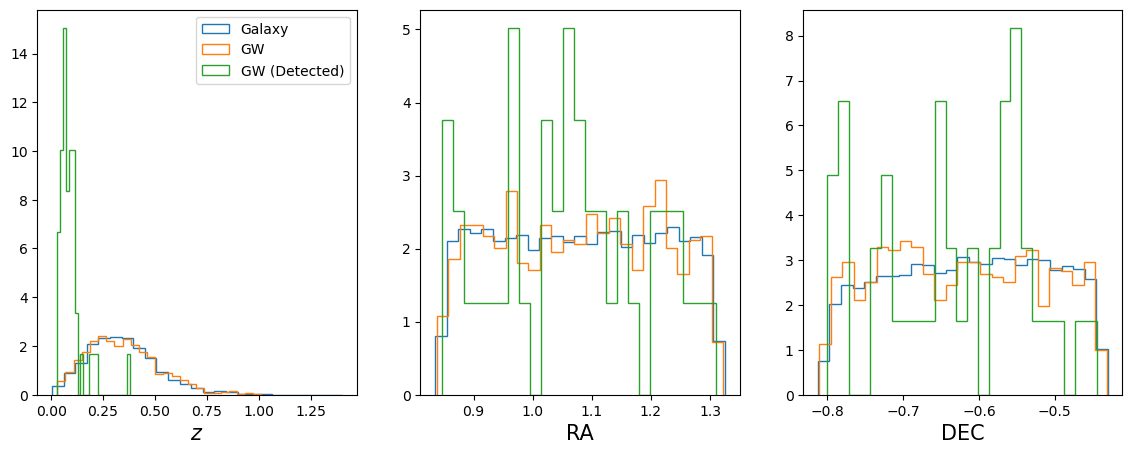

In [10]:
plt.figure(figsize=(14,5))

plt.subplot (1,3,1)
_ = plt.hist (z_true, bins=25, histtype='step', density=True, label='Galaxy')
_ = plt.hist (z, bins=25, histtype='step', density=True, label='GW')
_ = plt.hist (z[det_id], bins=25, histtype='step', density=True, label='GW (Detected)')

plt.xlabel(r'$z$', size=15)

plt.legend ()


plt.subplot (1,3,2)
_ = plt.hist (ra_true, bins=25, histtype='step', density=True, label='Galaxy')
_ = plt.hist (ra, bins=25, histtype='step', density=True, label='GW')
_ = plt.hist (ra[det_id], bins=25, histtype='step', density=True, label='GW')

plt.xlabel('RA', size=15)


plt.subplot (1,3,3)

_ = plt.hist (dec_true, bins=25, histtype='step', density=True, label='Galaxy')
_ = plt.hist (dec, bins=25, histtype='step', density=True, label='GW')
_ = plt.hist (dec[det_id], bins=25, histtype='step', density=True, label='GW (Detected)')

plt.xlabel('DEC', size=15)


In [8]:
det_id.size

22